In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv('data1.csv')
data.head()

,X1,X2,label
0,0.209122,0.461658,1
1,0.321425,0.117777,1
2,0.372524,0.011888,1
3,0.309895,0.004108,1
4,0.387019,0.329861,1


In [2]:
x=data.drop(['label'],axis=1)
y=data.loc[:,'label']
x.head()

,X1,X2
0,0.209122,0.461658
1,0.321425,0.117777
2,0.372524,0.011888
3,0.309895,0.004108
4,0.387019,0.329861


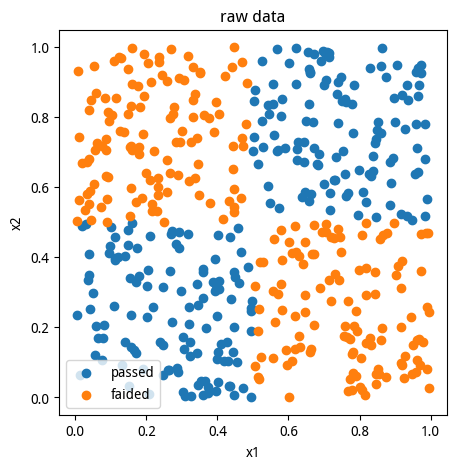

In [3]:
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=(5,5))
passed=plt.scatter(x.loc[:,'X1'][y==1],x.loc[:,'X2'][y==1])
faided=plt.scatter(x.loc[:,'X1'][y==0],x.loc[:,'X2'][y==0])
plt.legend((passed,faided),('passed','faided'))
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('raw data')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=10)
print(x_train.shape,x_test.shape,x.shape)

(321, 2) (159, 2) (480, 2)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Input

mlp=Sequential()
mlp.add(Input(shape=(2,)))
mlp.add(Dense(units=20,activation='sigmoid'))
mlp.add(Dense(units=1,activation='sigmoid'))
mlp.summary()

2025-11-03 20:28:29.452965: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-03 20:28:29.453012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-03 20:28:29.453942: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 20)                60        
                                                                 
 dense_1 (Dense)             (None, 1)                 21        
                                                                 
Total params: 81 (324.00 Byte)
Trainable params: 81 (324.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
mlp.compile(optimizer='adam',loss='binary_crossentropy')

In [37]:
mlp.fit(x_train,y_train,epochs=1000,verbose=1)

Epoch 1/1000
11/11 [==============================] - 0s 5ms/step - loss: 0.1704
Epoch 2/1000
11/11 [==============================] - 0s 4ms/step - loss: 0.1700
Epoch 3/1000
11/11 [==============================] - 0s 4ms/step - loss: 0.1694
Epoch 4/1000
11/11 [==============================] - 0s 4ms/step - loss: 0.1693
Epoch 5/1000
11/11 [==============================] - 0s 4ms/step - loss: 0.1691
Epoch 6/1000
11/11 [==============================] - 0s 3ms/step - loss: 0.1692
Epoch 7/1000
11/11 [==============================] - 0s 4ms/step - loss: 0.1691
Epoch 8/1000
11/11 [==============================] - 0s 4ms/step - loss: 0.1690
Epoch 9/1000
11/11 [==============================] - 0s 4ms/step - loss: 0.1689
Epoch 10/1000
11/11 [==============================] - 0s 3ms/step - loss: 0.1690
Epoch 11/1000
11/11 [==============================] - 0s 3ms/step - loss: 0.1689
Epoch 12/1000
11/11 [==============================] - 0s 3ms/step - loss: 0.1690
Epoch 13/1000
11/11 [====

In [38]:
y_train_predict = (mlp.predict(x_train) > 0.5).astype("int32")
from sklearn.metrics import accuracy_score
accuracy_train=accuracy_score(y_train,y_train_predict)
print(accuracy_train)

11/11 [==============================] - 0s 2ms/step
0.9501557632398754


In [39]:
y_test_predict = (mlp.predict(x_test) > 0.5).astype("int32")
accuracy_test=accuracy_score(y_test,y_test_predict)
print(accuracy_test)

5/5 [==============================] - 0s 2ms/step
0.9245283018867925


In [40]:
print(y_train_predict)
y_train_predict_from=pd.Series(i[0]for i in y_train_predict)
print(y_train_predict_from)

[[1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]


In [41]:
xx,yy=np.meshgrid(np.arange(0,1,0.01),np.arange(0,1,0.01))
x_range=np.c_[xx.ravel(),yy.ravel()]
y_range_predict=(mlp.predict(x_range)>0.5).astype("int32")
y_range_predict_from=pd.Series(i[0]for i in y_range_predict)
print(y_train_predict_from)

313/313 [==============================] - 0s 1ms/step
0      1
1      1
2      0
3      1
4      1
      ..
316    0
317    0
318    1
319    1
320    0
Length: 321, dtype: int32


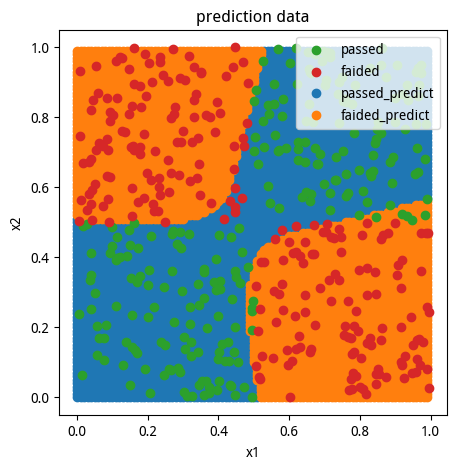

In [42]:
fig2=plt.figure(figsize=(5,5))
passed_predict=plt.scatter(x_range[:,0][y_range_predict_from==1],x_range[:,1][y_range_predict_from==1])
faided_predict=plt.scatter(x_range[:,0][y_range_predict_from==0],x_range[:,1][y_range_predict_from==0])
passed=plt.scatter(x.loc[:,'X1'][y==1],x.loc[:,'X2'][y==1])
faided=plt.scatter(x.loc[:,'X1'][y==0],x.loc[:,'X2'][y==0])
plt.legend((passed,faided,passed_predict,faided_predict),('passed','faided','passed_predict','faided_predict'))
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('prediction data')
plt.show()